# 03 — MWI Computation

Loads `MWI_raw.csv` and reshapes it into one row per participant with a column per movement metric. Computes the composite MWI score and merges it into `combined_data.csv`.

In [79]:
import pandas as pd

RAW_PATH    = '../data/raw/MWI_raw.csv'
OUTPUT_PATH = '../data/processed/MWI_clean.csv'

raw = pd.read_csv(RAW_PATH)
raw.columns = raw.columns.str.strip()
raw['participant'] = raw['participant'].str.strip()
raw['movement_name'] = raw['movement_name'].str.strip()
raw['side'] = raw['side'].str.strip()

print('Shape:', raw.shape)
print('Participants:', raw['participant'].nunique())
print()
print('Movements:')
print(raw['movement_name'].value_counts())

Shape: (227, 27)
Participants: 25

Movements:
movement_name
Standing Hip Abduction         50
Kneeling Knee Flexion          49
Shoulder Flexion               28
Unilateral Hip Extension       27
Prone Trunk Extension          25
Bilateral Leg Straddle         24
Shoulder Stick Pass-Through    24
Name: count, dtype: int64


## Step 1 — Extract mi4l for bilateral / unilateral movements

In [80]:
# Movements where we take mi4l directly
# Maps (movement_name, side) → output column name
MI4L_TARGETS = [
    ('Bilateral Leg Straddle',  'both',  'bilateral_leg_straddle_mi4l'),
    ('Kneeling Knee Flexion',   'left',  'kneeling_knee_flexion_left_mi4l'),
    ('Kneeling Knee Flexion',   'right', 'kneeling_knee_flexion_right_mi4l'),
    ('Prone Trunk Extension',   'both',  'prone_trunk_extension_mi4l'),
    ('Shoulder Flexion',        'left',  'shoulder_flexion_left_mi4l'),
    ('Shoulder Flexion',        'right', 'shoulder_flexion_right_mi4l'),
    ('Standing Hip Abduction',  'left',  'standing_hip_abduction_left_mi4l'),
    ('Standing Hip Abduction',  'right', 'standing_hip_abduction_right_mi4l'),
    ('Unilateral Hip Extension','both',  'unilateral_hip_extension_mi4l'),
]

frames = []

for movement, side, col_name in MI4L_TARGETS:
    subset = raw[
        (raw['movement_name'] == movement) &
        (raw['side'] == side)
    ][['participant', 'mi4l']].copy()

    subset['mi4l'] = pd.to_numeric(subset['mi4l'], errors='coerce')

    # If a participant has multiple trials, take the mean
    subset = subset.groupby('participant')['mi4l'].mean().reset_index()
    subset = subset.rename(columns={'mi4l': col_name})

    frames.append(subset)

# Start from the full participant list
participants = raw[['participant']].drop_duplicates().reset_index(drop=True)

df = participants.copy()
for frame in frames:
    df = df.merge(frame, on='participant', how='left')

print(f'Rows: {len(df)}  Columns: {df.columns.tolist()}')
df

Rows: 25  Columns: ['participant', 'bilateral_leg_straddle_mi4l', 'kneeling_knee_flexion_left_mi4l', 'kneeling_knee_flexion_right_mi4l', 'prone_trunk_extension_mi4l', 'shoulder_flexion_left_mi4l', 'shoulder_flexion_right_mi4l', 'standing_hip_abduction_left_mi4l', 'standing_hip_abduction_right_mi4l', 'unilateral_hip_extension_mi4l']


,participant,bilateral_leg_straddle_mi4l,kneeling_knee_flexion_left_mi4l,kneeling_knee_flexion_right_mi4l,prone_trunk_extension_mi4l,shoulder_flexion_left_mi4l,shoulder_flexion_right_mi4l,standing_hip_abduction_left_mi4l,standing_hip_abduction_right_mi4l,unilateral_hip_extension_mi4l
0,P08,0.033998,0.184866,0.198227,0.260711,-0.004490,-0.007708,0.361188,0.451010,NaN
1,P10,0.038877,0.091269,0.126759,0.390029,NaN,NaN,0.335768,0.065962,0.232413
2,P11,0.250372,0.263767,0.140053,0.496443,-0.000046,0.007012,NaN,0.471015,0.297405
3,P13,NaN,0.169420,0.165560,0.476829,NaN,NaN,0.272357,0.316331,0.441928
4,P17,0.039579,0.052414,NaN,0.297383,0.003383,-0.006630,0.207150,0.220833,0.272837
5,P19,NaN,0.182107,0.319323,0.427669,0.018563,-0.002359,NaN,0.256899,0.262858
6,P21,0.172910,0.133880,0.197593,0.244696,-0.009064,0.005072,0.550876,0.523499,0.033743
7,P01,0.068984,NaN,0.091430,0.462152,NaN,179.539227,0.505179,0.519761,NaN
8,P05,0.035156,0.084167,0.163155,0.468120,NaN,NaN,0.349189,0.448450,0.199013
9,P09,NaN,0.035947,0.083656,0.380380,NaN,NaN,0.134646,0.275865,NaN


## Step 2 — Extract SSP for Shoulder Stick Pass-Through

In [81]:
# Extract SSP (Shoulder Stick Pass-Through) — stored as grip_ratio_normalized
# SSP score = 1 - grip_ratio_normalized (smaller grip ratio = better shoulder mobility)
subset = raw[
    (raw['movement_name'] == 'Shoulder Stick Pass-Through') &
    (raw['side'] == 'both')
][['participant', 'grip_ratio_normalized']].copy()

subset['grip_ratio_normalized'] = pd.to_numeric(subset['grip_ratio_normalized'], errors='coerce')

# If a participant has multiple trials, take the mean
subset = subset.groupby('participant')['grip_ratio_normalized'].mean().reset_index()
subset['shoulder_stick_pass_through_ssp'] = 1 - subset['grip_ratio_normalized']
subset = subset.drop(columns='grip_ratio_normalized')

# Merge into df
df = df.merge(subset, on='participant', how='left')
print('SSP values (1 - grip_ratio_normalized):')
print(df[['participant', 'shoulder_stick_pass_through_ssp']].to_string(index=False))

SSP values (1 - grip_ratio_normalized):
participant  shoulder_stick_pass_through_ssp
        P08                         0.650197
        P10                         0.668148
        P11                         0.728229
        P13                         0.547496
        P17                         0.661050
        P19                         0.697256
        P21                         0.679808
        P01                         0.668399
        P05                              NaN
        P09                              NaN
        P15                              NaN
        P16                         0.676167
        P20                         0.681062
        P23                         0.608624
        P03                         0.515611
        P06                         0.488419
        P12                         0.687429
        P18                         0.682533
        P22                         0.668479
        P24                         0.713739
        P25    

## Step 3 —  flag invalid mi4l rows

Rows where `mi4l_valid = False` have no mi4l value. This cell shows which participant–movement combinations are missing.

In [82]:
invalid = raw[
    raw['mi4l_valid'].astype(str).str.strip() == 'False'
][['participant', 'movement_name', 'side', 'qc_flags']]

print(f'Invalid mi4l rows: {len(invalid)}')
print()
print(invalid.to_string(index=False))

print()
print('Missing values in clean output:')
print(df.isnull().sum())

Invalid mi4l rows: 27

participant            movement_name  side                                                                                                                                                 qc_flags
        P10         Shoulder Flexion  left                                                                                    mi4l:prom_lt_arom:173.976+2.000<178.672;too_many_clipped_frames:0.961
        P10         Shoulder Flexion right                                                                                    mi4l:prom_lt_arom:173.480+2.000<178.709;too_many_clipped_frames:1.000
        P11   Standing Hip Abduction  left                                                                                                                    mi4l:prom_lt_arom:43.714+2.000<55.005
        P13   Bilateral Leg Straddle  both arom:fallback_movement_window;arom:low_valid_ratio:0.027<0.200;arom:no_valid_hold;arom:too_few_valid_frames:6<15;mi4l:prom_lt_arom:128.344+2.000<154.4

## Step 4 — Save

In [83]:
mwi_cols = [
    'bilateral_leg_straddle_mi4l',
    'kneeling_knee_flexion_left_mi4l',
    'kneeling_knee_flexion_right_mi4l',
    'prone_trunk_extension_mi4l',
    'standing_hip_abduction_left_mi4l',
    'standing_hip_abduction_right_mi4l',
    'unilateral_hip_extension_mi4l',
    'shoulder_stick_pass_through_ssp',
]

df['n_poses'] = df[mwi_cols].notna().sum(axis=1)
df['mwi'] = df[mwi_cols].sum(axis=1) / df['n_poses']
df[['participant', 'n_poses', 'mwi']]

,participant,n_poses,mwi
0,P08,7,0.305743
1,P10,8,0.243653
2,P11,7,0.378183
3,P13,7,0.341417
4,P17,7,0.250178
5,P19,6,0.357685
6,P21,8,0.317126
7,P01,6,0.385984
8,P05,7,0.249607
9,P09,5,0.182099


In [84]:
df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df.shape}')
df.round(4)

Saved: ../data/processed/MWI_clean.csv
Shape: (25, 13)


,participant,bilateral_leg_straddle_mi4l,kneeling_knee_flexion_left_mi4l,kneeling_knee_flexion_right_mi4l,prone_trunk_extension_mi4l,shoulder_flexion_left_mi4l,shoulder_flexion_right_mi4l,standing_hip_abduction_left_mi4l,standing_hip_abduction_right_mi4l,unilateral_hip_extension_mi4l,shoulder_stick_pass_through_ssp,n_poses,mwi
0,P08,0.0340,0.1849,0.1982,0.2607,-0.0045,-0.0077,0.3612,0.4510,NaN,0.6502,7,0.3057
1,P10,0.0389,0.0913,0.1268,0.3900,NaN,NaN,0.3358,0.0660,0.2324,0.6681,8,0.2437
2,P11,0.2504,0.2638,0.1401,0.4964,-0.0000,0.0070,NaN,0.4710,0.2974,0.7282,7,0.3782
3,P13,NaN,0.1694,0.1656,0.4768,NaN,NaN,0.2724,0.3163,0.4419,0.5475,7,0.3414
4,P17,0.0396,0.0524,NaN,0.2974,0.0034,-0.0066,0.2071,0.2208,0.2728,0.6611,7,0.2502
5,P19,NaN,0.1821,0.3193,0.4277,0.0186,-0.0024,NaN,0.2569,0.2629,0.6973,6,0.3577
6,P21,0.1729,0.1339,0.1976,0.2447,-0.0091,0.0051,0.5509,0.5235,0.0337,0.6798,8,0.3171
7,P01,0.0690,NaN,0.0914,0.4622,NaN,179.5392,0.5052,0.5198,NaN,0.6684,6,0.3860
8,P05,0.0352,0.0842,0.1632,0.4681,NaN,NaN,0.3492,0.4485,0.1990,NaN,7,0.2496
9,P09,NaN,0.0359,0.0837,0.3804,NaN,NaN,0.1346,0.2759,NaN,NaN,5,0.1821


## Step 5 — Add MWI to combined_data

In [85]:
SURVEY_PATH = '../data/processed/combined_data.csv'

mwi_lookup = (
    df[['participant', 'mwi']]
    .assign(name=lambda d: d['participant'].map(lambda x: NAME_MAP.get(x, x)))
    [['name', 'mwi']]
)

survey = pd.read_csv(SURVEY_PATH)
# Strip trailing spaces from survey names (artefact from Google Forms import)
survey['name'] = survey['name'].str.strip()
survey = survey.drop(columns=['mwi'], errors='ignore')
survey = survey.merge(mwi_lookup, on='name', how='left')

matched   = survey['mwi'].notna().sum()
unmatched = mwi_lookup[~mwi_lookup['name'].isin(survey['name'])]['name'].tolist()

survey.to_csv(SURVEY_PATH, index=False)
print(f'Saved: {SURVEY_PATH}')
print(f'Participants with MWI: {matched} / {len(survey)}')
if unmatched:
    print(f'Not matched to survey (excluded): {unmatched}')
print()
print(survey[['name', 'mwi']].dropna().to_string(index=False))

Saved: ../data/processed/combined_data.csv
Participants with MWI: 25 / 25

name      mwi
 P16 0.310957
 P03 0.261061
 P24 0.314544
 P22 0.255513
 P06 0.165492
 P12 0.365681
 P04 0.348187
 P19 0.357685
 P21 0.317126
 P05 0.249607
 P13 0.341417
 P09 0.182099
 P08 0.305743
 P20 0.357979
 P07 0.358620
 P01 0.385984
 P15 0.242828
 P17 0.250178
 P10 0.243653
 P25 0.310219
 P11 0.378183
 P14 0.109855
 P18 0.335961
 P23 0.229178
 P02 0.300946


In [86]:

#  Missing MWI per pose (shoulder flexion excluded) 
POSE_COLS = [c for c in df.columns
             if c not in ('participant', 'n_poses', 'mwi')
             and 'shoulder_flexion' not in c]

missing = (
    df[POSE_COLS].isna()
    .sum()
    .rename('n_missing')
    .to_frame()
    .assign(pct_missing=lambda x: (x['n_missing'] / len(df) * 100).round(1))
    .sort_values('n_missing', ascending=False)
)
missing.index.name = 'pose'

n_complete  = df[POSE_COLS].notna().all(axis=1).sum()
n_any_miss  = df[POSE_COLS].isna().any(axis=1).sum()
miss_counts = df[POSE_COLS].isna().sum(axis=1)
n_miss_1    = (miss_counts == 1).sum()
n_miss_2    = (miss_counts == 2).sum()
n_miss_3    = (miss_counts == 3).sum()

print(f'Total participants: {len(df)}')
print(f'Complete (no missing poses): {n_complete}')
print(f'At least one missing pose:   {n_any_miss}')
print(f'  missing 1 pose:  {n_miss_1}')
print(f'  missing 2 poses: {n_miss_2}')
print(f'  missing 3 poses: {n_miss_3}')
print(f'\nMissing MWI by pose:')
print(missing[missing["n_missing"] > 0].to_string())

#  Which participants are missing which poses 
missing_detail = df[df[POSE_COLS].isna().any(axis=1)][['participant'] + POSE_COLS].copy()
missing_detail = missing_detail.set_index('participant')
missing_detail = missing_detail.isna().replace({True: 'MISSING', False: ''})


Total participants: 25
Complete (no missing poses): 8
At least one missing pose:   17
  missing 1 pose:  12
  missing 2 poses: 4
  missing 3 poses: 1

Missing MWI by pose:
                                   n_missing  pct_missing
pose                                                     
bilateral_leg_straddle_mi4l                6         24.0
unilateral_hip_extension_mi4l              5         20.0
kneeling_knee_flexion_right_mi4l           3         12.0
standing_hip_abduction_left_mi4l           3         12.0
shoulder_stick_pass_through_ssp            3         12.0
kneeling_knee_flexion_left_mi4l            1          4.0
prone_trunk_extension_mi4l                 1          4.0
standing_hip_abduction_right_mi4l          1          4.0


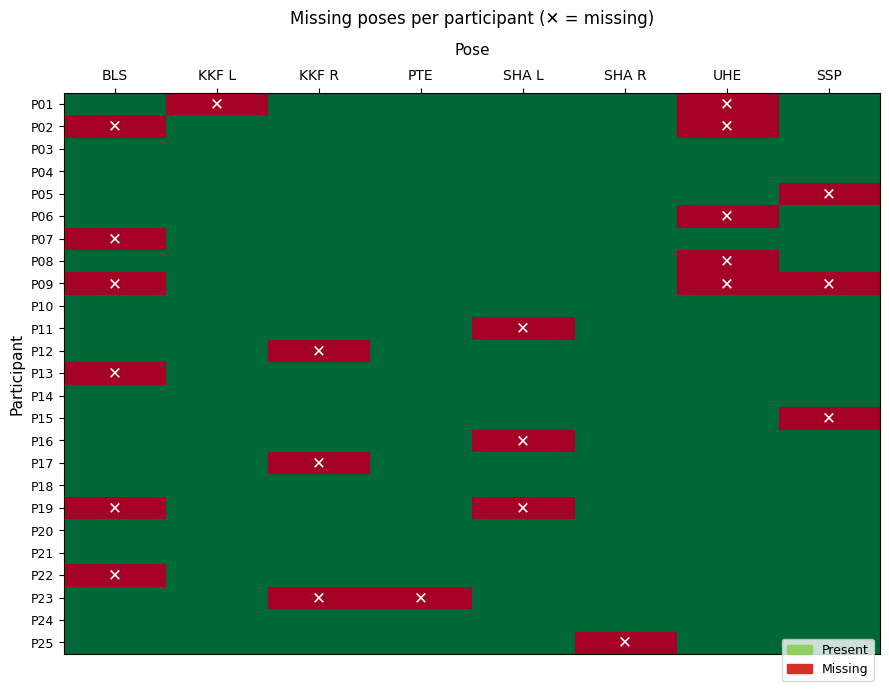

In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

POSE_COLS = [c for c in df.columns
             if c not in ('participant', 'n_poses', 'mwi')
             and 'shoulder_flexion' not in c]

SHORT = {
    'bilateral_leg_straddle_mi4l':        'BLS',
    'kneeling_knee_flexion_left_mi4l':    'KKF L',
    'kneeling_knee_flexion_right_mi4l':   'KKF R',
    'prone_trunk_extension_mi4l':         'PTE',
    'standing_hip_abduction_left_mi4l':   'SHA L',
    'standing_hip_abduction_right_mi4l':  'SHA R',
    'unilateral_hip_extension_mi4l':      'UHE',
    'shoulder_stick_pass_through_ssp':    'SSP',
}

miss = df.set_index('participant')[POSE_COLS].isna().astype(int)
miss = miss.sort_index()
miss.columns = [SHORT[c] for c in POSE_COLS]

fig, ax = plt.subplots(figsize=(9, 7))

ax.imshow(miss.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)

for i in range(miss.shape[0]):
    for j in range(miss.shape[1]):
        if miss.values[i, j] == 1:
            ax.text(j, i, '✕', ha='center', va='center',
                    fontsize=12, color='white', fontweight='bold')

ax.set_xticks(range(len(miss.columns)))
ax.set_xticklabels(miss.columns, fontsize=10)
ax.set_yticks(range(len(miss.index)))
ax.set_yticklabels(miss.index, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel('Pose', fontsize=11, labelpad=10)
ax.set_ylabel('Participant', fontsize=11)
ax.set_title('Missing poses per participant (✕ = missing)', fontsize=12, pad=14)

present_patch = mpatches.Patch(color='#91cf60', label='Present')
missing_patch = mpatches.Patch(color='#d73027', label='Missing')
ax.legend(handles=[present_patch, missing_patch], loc='lower right',
          bbox_to_anchor=(1.0, -0.06), fontsize=9)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.show()
